# Short-form inference experiments - analysis

Imports and setup:

In [ ]:
# stdlib
import itertools
import os
from collections import Counter
from typing import Tuple, Iterable
from multiprocessing import Pool
from pathlib import Path

# third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from tqdm import tqdm
import jiwer
from alt.alt_eval import metrics
from alt.alt_eval.tokenizer import WORD, BACKING, NONLEXICAL, Token
import rapidfuzz
import nltk

# first-party
from alt import util
from alt import evaluate
from alt.alt_types import EvalData, SongInfo

sns.set_theme()
project_root = Path(os.getcwd()).parent.parent
print(f"Home dir: {os.getenv('HOME')}")
print(f"Working dir: {os.getcwd()}")
print(f"Project root: {project_root}")


Home dir: /homes/js231
Working dir: /homes/js231/code/alt/expt/02-short
Project root: /homes/js231/code/alt


## Prepare data

Load data:

In [4]:
data: dict[Tuple[str, str, str], list[Tuple[SongInfo, jiwer.WordOutput]]] = dict()


def eval_song(name, uid) -> Tuple[SongInfo, jiwer.WordOutput]:
    songinfo = util.read_pz(f"../../build/{name}/infer/{uid}.pz")
    eval_data, wo = evaluate.eval_song(songinfo)
    songinfo.evaluate = eval_data
    return songinfo, wo


models = ["whisper"]  # override
levels = ["line", "verse"]
audios = ["mdx","original", "mdx_extra", "stem"]
for model, audio, level in tqdm(list(itertools.product(models, audios, levels))):
    if audio in ["original", "stem"]:
        name = f"02-short-{model}-{audio}-{level}"
    else:
        name = f"02-short-{audio}-{model}-separated-{level}"
    # read actual data
    data[(model, audio, level)] = []
    for idx in range(5):
        name_idx = f"{name}-{idx}"
        uids = util.read_summary(f"../../build/{name_idx}/infer/summary.json").infer.uids  # type: ignore
        uids = [uid for uid in uids if uid.endswith("jam-alt") or uid.endswith("musdb-alt")]
        results= Pool(20).starmap(
            eval_song, [(name_idx, uid) for uid in uids]
        )
        data[(model, audio, level)].extend(results)


  0%|          | 0/8 [00:00<?, ?it/s]/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at JamendoLyricsConfig.path: <class 'pathlib.Path'> It's advised to pass the correct marshmallow type to `mm_field`.
  warnings.warn(
/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at JamAltConfig.line_timings_path: <class 'pathlib.Path'> It's advised to pass the correct marshmallow type to `mm_field`.
  warnings.warn(
/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at MusdbAltConfig.musdb_dir: <class 'pathlib.Path'> It's advised to pass the correct marshmallow type to `mm_field`.
  warnings.warn(
/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unk

Convert to Dataframe: `df_samples` has one row per "sample", where a sample is a verse, line or song.

In [5]:
# Load jamendolyrics metadata
import csv
from pathlib import Path

jamendo_dir = Path("../../../../data/jamendolyrics")
with open(jamendo_dir / "JamendoLyrics.csv") as csvfile:
    jamendo_rows = list(csv.DictReader(csvfile))
jamendo_csv: dict[str, dict] = {row["Filepath"][:-4]: row for row in jamendo_rows}

In [ ]:
# for each sentence
tokenizer = metrics.LyricsTokenizer()
SHORT_DATASETS = ["jam-alt", "musdb-alt"]


def word_dist(w1, w2):
    if w1 is None or w2 is None:
        return np.nan
    w1 = w1.replace("'", "").replace("<nl>", "").replace("</nl>", "")
    w2 = w2.replace("'", "")
    return rapidfuzz.distance.Levenshtein.distance(w1, w2)


def get_ref_tags(ref: Token) -> set[str]:
    return {tag for tag in [NONLEXICAL, BACKING] if tag in ref.tags}


def get_chunk_edits(
    reference: list[Token],
    hypothesis: list[Token],
    chunk_type: str,
) -> list[Tuple[str, str, str, set]]:
    edits = []

    if chunk_type == "delete":
        assert len(hypothesis) == 0
        for token in reference:
            edits.append(("del", token.text, None, get_ref_tags(token)))
    elif chunk_type == "insert":
        assert len(reference) == 0
        for token in hypothesis:
            edits.append(("ins", None, token.text, {}))
    elif chunk_type in ["substitute", "equal"]:
        assert len(reference) == len(hypothesis)
        for token_ref, token_hyp in zip(reference, hypothesis):
            edits.append(
                (
                    "hit" if chunk_type == "equal" else "sub",
                    token_ref.text,
                    token_hyp.text,
                    get_ref_tags(token_ref),
                )
            )
    else:
        assert False, f"Unhandled chunk type: {chunk_type}"
    return edits


map_type = {
    "insert": "ins",
    "equal": "hit",
    "delete": "del",
    "substitute": "sub",
}


def per_sample_metrics(
    songinfo: SongInfo, wo: jiwer.WordOutput
) -> Tuple[list[dict], list[dict], list[dict]]:
    num_samples = len(wo.alignments)
    eval_data = songinfo.evaluate
    assert eval_data is not None
    assert len(eval_data.refs) == num_samples
    assert len(eval_data.hyps) == num_samples
    assert songinfo.infer is not None
    if songinfo.infer.lines:
        assert len(songinfo.infer.lines) == num_samples
        timings = [
            {"start": line.start, "end": line.end} for line in songinfo.infer.lines
        ]
    elif songinfo.infer.verses:
        assert len(songinfo.infer.verses) == num_samples
        timings = [
            {"start": verse.start, "end": verse.end} for verse in songinfo.infer.verses
        ]
    else:
        timings = [{}] * num_samples
    # EvalData.refs and EvalData.hyps and whisper output
    # ran through normalize_lyrics and add_nonlex_tags
    sample_rows = []
    chunk_rows = []
    edit_rows = []
    for idx, (alignment, ref, hyp, timing) in enumerate(
        zip(wo.alignments, eval_data.refs, eval_data.hyps, timings)
    ):
        ref_tokens = metrics.tokens_as_words(
            tokenizer(ref, language=songinfo.extract.language)
        )
        hyp_tokens = metrics.tokens_as_words(
            tokenizer(hyp, language=songinfo.extract.language)
        )
        edit_counts, _error_counts = metrics.process_alignments(
            [ref_tokens], [hyp_tokens], [alignment]
        )
        e = edit_counts[WORD]
        en = edit_counts[NONLEXICAL]
        eb = edit_counts[BACKING]
        if songinfo.extract.song_id in jamendo_csv:
            genre = jamendo_csv[songinfo.extract.song_id]["Genre"]
        else:
            genre = "none"
        # ref_ngram_dup = count_ngram_dup((token.text for token in ref_tokens), 5)
        # hyp_ngram_dup = count_ngram_dup((token.text for token in hyp_tokens), 5)
        # extra_ngram_dup = hyp_ngram_dup - ref_ngram_dup
        sample_rows.append(
            {
                "wer": (e.S + e.D + e.I) / (e.H + e.S + e.D),
                "hit": e.H,
                "sub": e.S,
                "del": e.D,
                "ins": e.I,
                # you can at least show that deletions of nonlexical lines
                # are a high percentage of the error rate
                # en.x + eb.x <= e.x for x in {H, S, D}
                "hit_nl": en.H,
                "sub_nl": en.S,
                "del_nl": en.D,
                "hit_bv": eb.H,
                "sub_bv": eb.S,
                "del_bv": eb.D,
                "len": (e.H + e.S + e.D),
                "uid": songinfo.extract.uid,
                "idx": idx,
                "ref": ref,
                "hyp": hyp,
                "dist": word_dist(ref, hyp),
                "start": timing.get("start", None),
                "end": timing.get("end", None),
                "language": songinfo.extract.language,
                "dataset": songinfo.extract.dataset_id,
                "genre": genre,
                "split": songinfo.extract.split,
            }
        )
        for idx, chunk in enumerate(alignment):
            chunk_hyp = hyp_tokens[chunk.hyp_start_idx : chunk.hyp_end_idx]
            chunk_ref = ref_tokens[chunk.ref_start_idx : chunk.ref_end_idx]
            chunk_row = {
                    "typ": map_type[chunk.type],
                    "ref": " ".join(token.text for token in chunk_ref),
                    "hyp": " ".join(token.text for token in chunk_hyp),
                    # len will be same for sub/hit and the non-zero one for del/ins
                    "len": max(
                        chunk.hyp_end_idx - chunk.hyp_start_idx,
                        chunk.ref_end_idx - chunk.ref_start_idx,
                    ),
                    "uid": songinfo.extract.uid,
                    "dataset": songinfo.extract.dataset_id,
                    "language": songinfo.extract.language,
                    "split": songinfo.extract.split,
                    "idx": idx,
                    "nl": 0,
                    "bv": 0
                }
            for op, edit_ref, edit_hyp, tags in get_chunk_edits(
                chunk_ref, chunk_hyp, chunk.type
            ):
                if NONLEXICAL in tags:
                    chunk_row["nl"] += 1
                if BACKING in tags:
                    chunk_row["bv"] += 1
                edit_rows.append(
                    {
                        "typ": op,
                        "ref": edit_ref,
                        "hyp": edit_hyp,
                        "uid": songinfo.extract.uid,
                        "dataset": songinfo.extract.dataset_id,
                        "language": songinfo.extract.language,
                        "genre": genre,
                        "dist": word_dist(edit_ref, edit_hyp),
                        "nl": NONLEXICAL in tags,
                        "bv": BACKING in tags,
                        "split": songinfo.extract.split,
                    }
                )
            chunk_rows.append(chunk_row)
    return (sample_rows, chunk_rows, edit_rows)


# execute
# system: identifiers -- sample_data: results of eval_song for that system
def sample_metrics(
    system: Tuple[str, str, str], sample_data: list[Tuple[SongInfo, jiwer.WordOutput]]
) -> Tuple[list[dict], list[dict]]:
    (model, audio, level) = system
    system_dict = {"model": model, "audio": audio, "level": level}
    rows = [
        per_sample_metrics(s, wo)
        for s, wo in sample_data
        if s.extract.dataset_id in SHORT_DATASETS
    ]
    sample_rows = [sample | system_dict for samples, _, _ in rows for sample in samples]
    chunk_rows = [chunk | system_dict for _, chunks, _ in rows for chunk in chunks]
    edit_rows = [edit | system_dict for _, _, edits in rows for edit in edits]
    return sample_rows, chunk_rows, edit_rows


system_rows = Pool(20).starmap(sample_metrics, data.items())
df_samples = pd.DataFrame(
    [sample_row for sample_rows, _, _ in system_rows for sample_row in sample_rows]
)
df_chunks = pd.DataFrame(
    [chunk_row for _, chunk_rows, _ in system_rows for chunk_row in chunk_rows]
)
df_edits = pd.DataFrame(
    [edit_row for _, _, edit_rows in system_rows for edit_row in edit_rows]
)
util.write_pz(project_root / "share" / "data_short.pz", (df_samples, df_chunks, df_edits))


## Plots and Analysis

In [7]:
(df_samples, df_chunks, df_edits) = util.read_pz(project_root / "share" / "data_short.pz")

### Segment distribution summary

In [23]:
for model in ["whisper"]:
    display(model)
    df = df_samples.query(
        "model == @model and audio == 'original' & level != 'song'"
    ).drop(["wer", "uid", "language", "idx", "ref", "hyp", "model"], axis=1)

    # print basic stats
    df["len_secs"] = df["end"] - df["start"]
    pivot_table = df.pivot_table(
        index=["dataset", "level"],
        values="len_secs",
        aggfunc=["mean", "std", "min", "max", lambda row: int(len(row)/5)],
    ).dropna()
    # Rename columns and index
    pivot_table.columns = ["Mean", "Std. Dev", "Min.", "Max.", "Count"]
    pivot_table.index.names = ["Dataset", "Type"]
    pivot_table.columns = [f"\\textbf{{{col}}}" for col in pivot_table.columns]
    pivot_table.index.names = [f"\\textbf{{{col}}}" for col in pivot_table.index.names]
    pivot_table = pivot_table.rename(index={"line": "Line", "verse": "Group", "jam-alt": "JAM-ALT", "musdb-alt": "MUSDB-ALT"})
    display(pivot_table)
    latex_table = pivot_table.format_index(escape="latex").format_index(escape="latex", axis=1)
    (project_root / "share" / "segment_length_summary.tex").write_text(
        latex_table.to_latex(), encoding="utf-8"
    )
    print(latex_table.to_latex(hrules=True, column_format="ll|rrrrr", float_format="%.2f"))

'whisper'

\textbf{Mean}  \textbf{Std. Dev}  \
\textbf{Dataset} \textbf{Type}                                     
JAM-ALT          Line                3.521685           1.797086   
                 Group              20.443648           5.510764   
MUSDB-ALT        Line                4.592930           2.388762   
                 Group              19.842312           5.510691   

                                \textbf{Min.}  \textbf{Max.}  \textbf{Count}  
\textbf{Dataset} \textbf{Type}                                                
JAM-ALT          Line                    0.44          17.66            3445  
                 Group                   3.64          29.93             613  
MUSDB-ALT        Line                    1.22          23.82            1488  
                 Group                   2.27          29.93             359

AttributeError: 'DataFrame' object has no attribute 'format_index'

### Overall results by model/level/audio on each dataset

Generate tables of `{ins|del|sub}_rate` for each dataset, with original/separated and line/verse level evalution.
- Reduction in error mostly due to reduction in substitutions, with secondary contribution from reduction in insertions
- deletions slightly higher for verses - model has a bit more freedom to pick what to listen to?
- TODO: Box Plots!

In [ ]:
plot = True
rename_dict = {
    "sub_rate": "SR",
    "del_rate": "DR",
    "ins_rate": "IR",
    "wer": "WER",
    "hal_rate": "IR_Hal",
    "del_nl_rate": "DR_NL",
    "del_bv_rate": "DR_BV",
}
rename_dict_dataset = {
    "jam-alt": "JAM-ALT",
    "musdb-alt": "MUSDB-ALT",
}
rename_dict_audio = {
    "original": "Original Mix",
    "mdx_extra": "Separated (mdx_extra)",
    "mdx": "Separated (mdx)",
    "stem": "Vocal Stem",
}
rename_dict_level = {
    "verse": "Group",
    "line": "Line"
}


def map_chunk(row):
    for typ in ["hit", "sub", "ins", "del"]:
        row[typ] = row["len"] if row["typ"] == typ else 0
    row["hal"] = row["ins"] if row["ins"] > 10 else 0
    return row

for model in ["whisper"]:
    # Convert chunks to hit/sub/ins/del/hal counts
    df = df_chunks.query("split == 'test' and model == @model and level != 'song'")[["level", "typ", "len", "dataset", "audio", "nl", "bv"]]
    df["hit"] = (df["typ"] == "hit") * df["len"]
    df["sub"] = (df["typ"] == "sub") * df["len"]
    df["ins"] = (df["typ"] == "ins") * df["len"]
    df["del"] = (df["typ"] == "del") * df["len"]
    df["del_nl"] = (df["typ"] == "del") * df["nl"]
    df["del_bv"] = (df["typ"] == "del") * df["bv"]
    df["hal"] = (df["ins"] > 10) * df["ins"]

    df = df.groupby(["dataset", "audio", "level"]).sum().reset_index()

    # compute rates
    df["ref_len"] = df["sub"] + df["hit"] + df["del"]
    df["wer"] = (df["sub"] + df["del"] + df["ins"]) / df["ref_len"]
    df["ins_rate"] = df["ins"] / df["ref_len"]
    df["del_rate"] = df["del"] / df["ref_len"]
    df["del_nl_rate"] = df["del_nl"] / df["ref_len"]
    df["del_bv_rate"] = df["del_bv"] / df["ref_len"]
    df["sub_rate"] = df["sub"] / df["ref_len"]
    df["hal_rate"] = df["hal"] / df["ref_len"]

    # Create table
    df = df.sort_values("audio").reset_index()
    df["audio"] = pd.Categorical(
        df["audio"], categories=["original", "mdx", "mdx_extra", "stem"], ordered=True
    )
    df["level"] = pd.Categorical(
        df["level"], categories=["verse", "line"], ordered=True
    )
    df[["wer", "sub_rate", "del_rate", "ins_rate", "hal_rate", "del_nl_rate", "del_bv_rate"]] *= 100
    pivot_table = df.pivot(
        index=["level", "audio"],
        columns=["dataset"],
        values=["wer", "sub_rate", "del_rate", "ins_rate", "hal_rate", "del_nl_rate", "del_bv_rate"],
    )
    pivot_table = (
        pivot_table.swaplevel(0, 1, axis=1)
        .sort_index(axis=1, level=0, sort_remaining=False)
        .rename(columns=rename_dict_dataset, level=0)
        .rename(columns=rename_dict, level=1)
        .rename(index=rename_dict_audio, level=1)
        .rename(index=rename_dict_level, level=0)
        .rename_axis(
            index={"level": "Type", "audio": "Audio"}, columns={"dataset": "Dataset"})
    )

    pivot_table = (
        pivot_table.style.format(
            "{:.2f}",
            na_rep="-",
            subset=pd.IndexSlice[:, pd.IndexSlice[:, ["WER", "SR", "DR", "IR", "DR_NL", "DR_BV", "IR_Hal"]]],
        )
        .highlight_min(
            axis=0,
            props="font-weight:bold;",
            subset=pd.IndexSlice[pd.IndexSlice[["Group"], ["Original Mix", "Separated (mdx)", "Separated (mdx_extra)"]], :]
        )
        .highlight_min(
            axis=0,
            props="font-weight:bold;",
            subset=pd.IndexSlice[pd.IndexSlice[["Line"], ["Original Mix", "Separated (mdx)", "Separated (mdx_extra)"]], :]
        )
    )

    display(pivot_table)
    latex_table = pivot_table.format_index(escape="latex").format_index(
        escape="latex", axis=1
    )
    (project_root / "share" / "verse_error_table.tex").write_text(
        latex_table.to_latex(convert_css=True), encoding="utf-8"
    )
    print(latex_table.to_latex(convert_css=True), encoding="utf-8")
    # if plot:
    #     # Plot stacked bar chart
    #     df.set_index(["audio", "level"])[
    #         ["sub_rate", "del_rate", "ins_rate"]
    #     ].rename(
    #         columns={"sub_rate": "sub", "del_rate": "del", "ins_rate": "ins"}
    #     ).plot(kind="bar", stacked=True, ax=ax[idx])
    #     ax[idx].set_title(f"Stacked Bar Chart for {dataset}")
    #     ax[idx].set_ylabel("Error Rates (%)")
    #     ax[idx].set_xlabel("Audio and Level")
    #     plt.xticks(rotation=45)
    # if plot:
    #     plt.show()

SyntaxError: unmatched ')' (3541594410.py, line 106)

### Line-level error rate plots

In [10]:
FONTSIZE = 14
plot = False
for model in ["whisper"]:
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
        display(model)
    else:
        axes = [None, None]
    datasets = ["jam-alt", "musdb"]
    for ax, dataset in zip(axes, datasets):
        df = df_samples.query(
            "split =='test' and model == @model and dataset==@dataset and level == 'line'"
        ).copy()
        df["level"] = df["level"].replace({"line": "Line", "verse": "Group"})
        df["audio"] = df["audio"].replace(
            {"original": "Original", "mdx": "Separated (mdx)", "mdx_extra": "Separated (mdx_extra)", "stem": "Stem"}
        )
        if plot:
            sns.boxplot(
                data=df,
                x="level",
                y="wer",
                hue="audio",
                ax=ax,
                showmeans=True,
                showfliers=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": "8",
                },
            )
            ax.set_title(dataset.upper(), fontsize=FONTSIZE + 2)
            ax.set_ylabel("WER", fontsize=FONTSIZE)
            ax.set_xlabel("level", fontsize=FONTSIZE)
            ax.tick_params(axis="both", which="major", labelsize=FONTSIZE)
            ax.legend(fontsize=FONTSIZE)
            ax.set_xlabel("level")
            plt.tight_layout()
            plt.show()
            fig.savefig(project_root / "share" / "short_wer_box.pdf")


### Grouped lines evaluation plots and Table

'whisper_nofb'

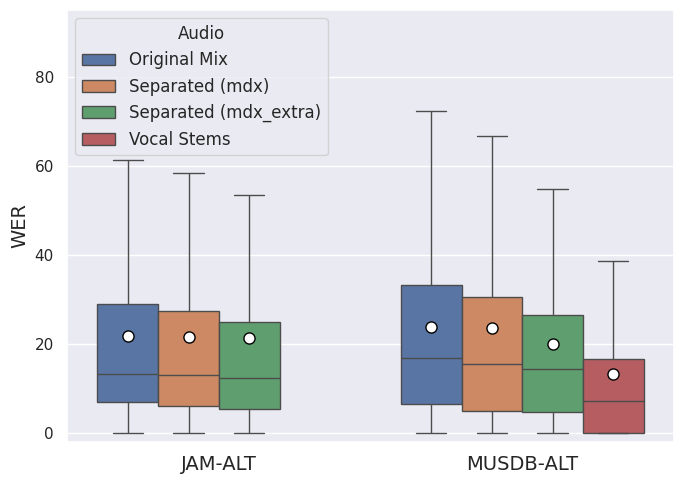

In [9]:
FONTSIZE = 14
for model in ["whisper_nofb"]:
    display(model)
    fig, ax = plt.subplots(1, 1, figsize=(7, 5), sharey=True)
    df = df_samples.query("split =='test' and model == @model and level == 'verse'").copy()
    df["audio"] = pd.Categorical(
        df["audio"].replace(
            {
                "original": "Original Mix",
                "mdx": "Separated (mdx)",
                "mdx_extra": "Separated (mdx_extra)",
                "stem": "Vocal Stems",
            }
        ),
        categories=["Original Mix", "Separated (mdx)", "Separated (mdx_extra)", "Vocal Stems"],
        ordered=True,
    )
    df["dataset"] = df["dataset"].str.upper()
    df["wer"] = df["wer"] * 100
    sns.boxplot(
        data=df,
        x="dataset",
        y="wer",
        hue="audio",
        ax=ax,
        showmeans=True,
        showfliers=False,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": "8",
        },
    )
    ax.get_xaxis().label.set_visible(False)
    ax.set_ylabel("WER", fontsize=FONTSIZE)
    # ax.set_xlabel("Dataset", fontsize=FONTSIZE-2)
    plt.xticks(fontsize=FONTSIZE)
    ax.set_ylim(-2,95)
    # ax.tick_params(axis="both", which="major", labelsize=FONTSIZE)
    plt.legend(loc="upper left", title="Audio",prop={'size':FONTSIZE-2} , title_fontsize=FONTSIZE-2)
    plt.tight_layout()
    plt.show()
    fig.savefig(project_root / "share" / "short_wer_box_2.pdf")


### Nonlexical / backing vocal analysis

Findings: 
 - NL / BV are  70/60%deleted and 10% subbed
 - Form a consistent proportion of the deletions over verses
 - Deletions slightly lower and subs slightly higher for separated rather than original

In [19]:
# Want to show - table
#   - bracketed and nonlexical deletions are large and consistent part of the deletions and a smaller and consistent part of the error
#   - pivot table: audio rows columns are
def get_props(rows: pd.DataFrame):
    nl = rows.query("nl == True").groupby("type").size()
    bv = rows.query("bv == True").groupby("type").size()
    both = rows.query("nl == True or bv == True").groupby("type").size()
    total = rows.groupby("type").size().reindex(["hit", "sub", "del"], fill_value=0)

    # proportions of deletions
    both_del_prop = both["del"] / total["del"]
    nl_del_prop = nl["del"] / total["del"]
    bv_del_prop = bv["del"] / total["del"]
    # proportions of deletions
    both_sub_prop = both["sub"] / total["sub"]
    nl_sub_prop = nl["sub"] / total["sub"]
    bv_sub_prop = bv["sub"] / total["sub"]

    return pd.Series(
        {
            "both_del_prop": both_del_prop,
            "nl_del_prop": nl_del_prop,
            "bv_del_prop": bv_del_prop,
            "both_sub_prop": both_sub_prop,
            "nl_sub_prop": nl_sub_prop,
            "bv_sub_prop": bv_sub_prop,
        }
    )


def get_rates(rows: pd.DataFrame):
    nl = rows.query("nl == True").groupby("type").size()
    bv = rows.query("bv == True").groupby("type").size()

    nl_del_rate = nl["del"] / (nl["hit"] + nl["sub"] + nl["del"])
    bv_del_rate = bv["del"] / (bv["hit"] + bv["sub"] + bv["del"])
    nl_sub_rate = nl["sub"] / (nl["hit"] + nl["sub"] + nl["del"])
    bv_sub_rate = bv["sub"] / (bv["hit"] + bv["sub"] + bv["del"])

    return pd.Series(
        {
            "nl_del_rate": nl_del_rate,
            "bv_del_rate": bv_del_rate,
            "nl_sub_rate": nl_sub_rate,
            "bv_sub_rate": bv_sub_rate,
        }
    )


for model in ["whisper"]:
    df = (
        df_edits.query("model == @model and dataset == 'jam-alt' and level == 'verse'")
        .groupby("audio")
        .apply(get_props)
    )
    display((df * 100).style.format("{:.1f}"))
    df = (
        df_edits.query("model == @model and dataset == 'jam-alt' and level == 'verse'")
        .groupby("audio")
        .apply(get_rates)
    )
    display((df * 100).style.format("{:.1f}"))


/tmp/ipykernel_1332678/357496851.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_props)


,typ,ref,hyp,uid,dataset,language,genre,dist,nl,bv,split,model,audio,level
audio,,,,,,,,,,,,,,


/tmp/ipykernel_1332678/357496851.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_rates)


,typ,ref,hyp,uid,dataset,language,genre,dist,nl,bv,split,model,audio,level
audio,,,,,,,,,,,,,,


### Results by genre and language

In [20]:
for model in ["whisper"]:
    df = df_samples.query(
        "dataset == 'jam-alt' and level == 'verse' and model == @model"
    )[["sub", "ins", "del", "len", "audio", "genre", "uid"]]
    df = df.groupby(["audio", "genre"]).agg(
        sub=("sub", "sum"),
        ins=("ins", "sum"),
        dels=("del", "sum"),
        len=("len", "sum"),
        num_songs=("uid", "nunique")
    ).reset_index()
    df["wer"] = (df["sub"] + df["dels"] + df["ins"]) / df["len"]
    pv = df.pivot_table(index=["audio"], values="wer", columns=["genre"])
    display((pv * 100).style.format("{:.2f}"))
    pv_num_songs = df.pivot_table(index=["audio"], values="num_songs", columns=["genre"])
    display(pv_num_songs)

audio


genre
audio


In [ ]:
for model in ["whisper"]:
    df = df_samples.query(
        "dataset == 'jam-alt' and level == 'verse' and model == @model"
    )[["sub", "ins", "del", "len", "audio", "language"]]
    df = df.groupby(["audio", "language"]).sum().reset_index()
    df["wer"] = (df["sub"] + df["del"] + df["ins"]) / df["len"]
    pv = df.pivot_table(index=["audio"], values="wer", columns=["language"])
    display((pv * 100).style.format("{:.2f}"))

language,de,en,es,fr
audio,,,,
mdx_extra,13.94,29.12,16.00,25.46
original,16.31,26.40,14.56,24.91


### Find hallucinations

Inspect largest insertions and substitutions for jam-alt/musdb with different audios:
- Results seem to indicate that increasing length and better SS both reduce the number of long insertions

In [13]:
datasets = ["jam-alt", "dali_gt", "musdb"]
for model in ["whisper"]:
    for level in ["line", "verse"]:
        display(level)
        df = (
            df_samples.query(
                "dataset != 'jamendolyrics' and model == @model and level == @level"
            )
            .drop(["wer", "uid", "language", "idx", "start", "end", "model"], axis=1)
            .groupby(["dataset", "audio", "level"])
        )

        for (dataset, audio, level), group in df:
            if level == level and audio in ["original", "mdx_extra", "stem"]:
                group = group.copy()
                group["cer"] = group["dist"] / group["ref"].str.len()
                cols = ["ref", "hyp", "cer", "dist", "ins", "sub", "del"]
                hallucinations = (
                    group.query("ins > 5 and cer > 0.8")
                    .nlargest(20, "cer")
                    .sort_values("cer", ascending=False)
                )
                # longest_insertions["cer"] = longest_insertions["dist"] / longest_insertions["ref"].str.len()
                # longest_insertions = longest_insertions.sort_values("cer", ascending=False)
                ins_sum = group["ins"].sum()
                num_long = len(hallucinations["ins"])
                ins_hal = hallucinations["ins"].sum()
                print(
                    f"Dataset: {dataset}, Audio: {audio}, Total: {ins_sum}, long: {ins_hal}, num_long: {num_long} ratio: {(ins_hal / ins_sum):.2f}"
                )
                # display(longest_insertions[["ins", "sub", "dist", "rel_dist",  "ref", "hyp"]])

'line'

Dataset: jam-alt, Audio: mdx_extra, Total: 854, long: 29, num_long: 4 ratio: 0.03
Dataset: jam-alt, Audio: original, Total: 916, long: 37, num_long: 5 ratio: 0.04
Dataset: musdb, Audio: mdx_extra, Total: 1672, long: 563, num_long: 18 ratio: 0.34
Dataset: musdb, Audio: original, Total: 2327, long: 949, num_long: 17 ratio: 0.41
Dataset: musdb, Audio: stem, Total: 1360, long: 460, num_long: 12 ratio: 0.34


'verse'

Dataset: jam-alt, Audio: mdx_extra, Total: 848, long: 438, num_long: 4 ratio: 0.52
Dataset: jam-alt, Audio: original, Total: 409, long: 6, num_long: 1 ratio: 0.01
Dataset: musdb, Audio: mdx_extra, Total: 1183, long: 405, num_long: 6 ratio: 0.34
Dataset: musdb, Audio: original, Total: 1590, long: 651, num_long: 14 ratio: 0.41
Dataset: musdb, Audio: stem, Total: 1363, long: 700, num_long: 9 ratio: 0.51
